## Problem Statement

### Business Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

### Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Installing and Importing the necessary libraries

In [9]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.5.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the below.*

In [11]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score


# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import RandomizedSearchCV

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Import Dataset

In [13]:
visa = pd.read_csv('EasyVisa.csv') ## Read the data

In [14]:
# Copying data to another variable to avoid making changes to the original data
data = visa.copy()

## Overview of the Dataset

#### View the first and last 5 rows of the dataset

In [17]:
data.head() # First 5 rows of the dataset

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [18]:
data.tail() # Last 5 rows of the dataset

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


#### Understand the shape of the dataset

In [20]:
data.shape # The shape (aka rows, columns) in the dataset

(25480, 12)

In [21]:
data.size # The size (aka total numbers of elements) in the dataset

305760

#### Check the data types of the columns for the dataset

In [23]:
# Display a concise summary of the DataFrame 'data'
# Shows information about index dtype and column dtypes, non-null values and memory usage
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


##### **Observations:**
1. There are a total of 12 columns
2. One column is float64, two are int,64 and nine are object dataTypes columns in the dataset
3. Total rows 25480
4. There are no missing values in any of these columns.
5. The memory the DataFrame is using is approximately 2.3 MB

In [25]:
data.duplicated().sum() # Check for duplicate values

0

##### **Observations:**
There is no duplicate row in the dataFrame

In [27]:
data.describe().T # Check Statastical summary of numeric data

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


In [28]:
data.describe(include=["object"]).T # Check Statastical summary of non-numeric data

,count,unique,top,freq
case_id,25480,25480,EZYV01,1
continent,25480,6,Asia,16861
education_of_employee,25480,4,Bachelor's,10234
has_job_experience,25480,2,Y,14802
requires_job_training,25480,2,N,22525
region_of_employment,25480,5,Northeast,7195
unit_of_wage,25480,4,Year,22962
full_time_position,25480,2,Y,22773
case_status,25480,2,Certified,17018


In [29]:
# Identify unique values of categorical data columns
cat_cols = data.select_dtypes(include="object").columns  # columns of object data type

# Print a separator line for better readability
for col in cat_cols:
    print("Unique values in the column", col, "are:")
    # Display count of each unique value in the column
    print(data[col].value_counts())     
    # Print a separator line for better readability
    print("=" * 60)     

Unique values in the column case_id are:
EZYV01       1
EZYV16995    1
EZYV16993    1
EZYV16992    1
EZYV16991    1
            ..
EZYV8492     1
EZYV8491     1
EZYV8490     1
EZYV8489     1
EZYV25480    1
Name: case_id, Length: 25480, dtype: int64
Unique values in the column continent are:
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: continent, dtype: int64
Unique values in the column education_of_employee are:
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: education_of_employee, dtype: int64
Unique values in the column has_job_experience are:
Y    14802
N    10678
Name: has_job_experience, dtype: int64
Unique values in the column requires_job_training are:
N    22525
Y     2955
Name: requires_job_training, dtype: int64
Unique values in the column region_of_employment are:
Northeast    7195
South        7017
West         6586
Midwest      4307
I

In [30]:
# Drop case_id column before EDA, as it has no meaning for analyses and modeling
# To explain more, since all the values in case_id are unique, we are dropping the column case_id
data.drop("case_id", axis=1, inplace=True)

## Exploratory Data Analysis (EDA)

#### Let's check the statistical summary of the data

In [33]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN
full_time_position,25480,2,Y,22773,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Fixing the negative values in number of employees columns

In [35]:
data.loc[data['no_of_employees'] < 0].shape

(33, 11)

In [36]:
# Take the absolute values for number of employees and convert all values in this column to their absolute values
data['no_of_employees'] = abs(data['no_of_employees'])

#### Let's check the count of each unique category in each of the categorical variables

In [38]:
# Get a list of all categorical columns (those with object data type)
cat_col = list(data.select_dtypes("object").columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    # Display frequency distribution of values in the current column
    print(data[column].value_counts())
    print("-" * 50)

Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: continent, dtype: int64
--------------------------------------------------
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: education_of_employee, dtype: int64
--------------------------------------------------
Y    14802
N    10678
Name: has_job_experience, dtype: int64
--------------------------------------------------
N    22525
Y     2955
Name: requires_job_training, dtype: int64
--------------------------------------------------
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: region_of_employment, dtype: int64
--------------------------------------------------
Year     22962
Hour      2157
Week       272
Month       89
Name: unit_of_wage, dtype: int64
--------------------------------------------------
Y    22773
N     2707
Name: full_time_position, dty

### Univariate Analysis

In [40]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns


def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize
    )

    sns.boxplot(data=data, x=feature, ax=ax_box, showmeans=True, color="violet")
    if bins:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist, bins=bins)
    else:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist)

    ax_hist.axvline(data[feature].mean(), color="green", linestyle="--", label='Mean')
    ax_hist.axvline(data[feature].median(), color="black", linestyle="-", label='Median')
    ax_hist.legend()

    plt.tight_layout()
    plt.show()


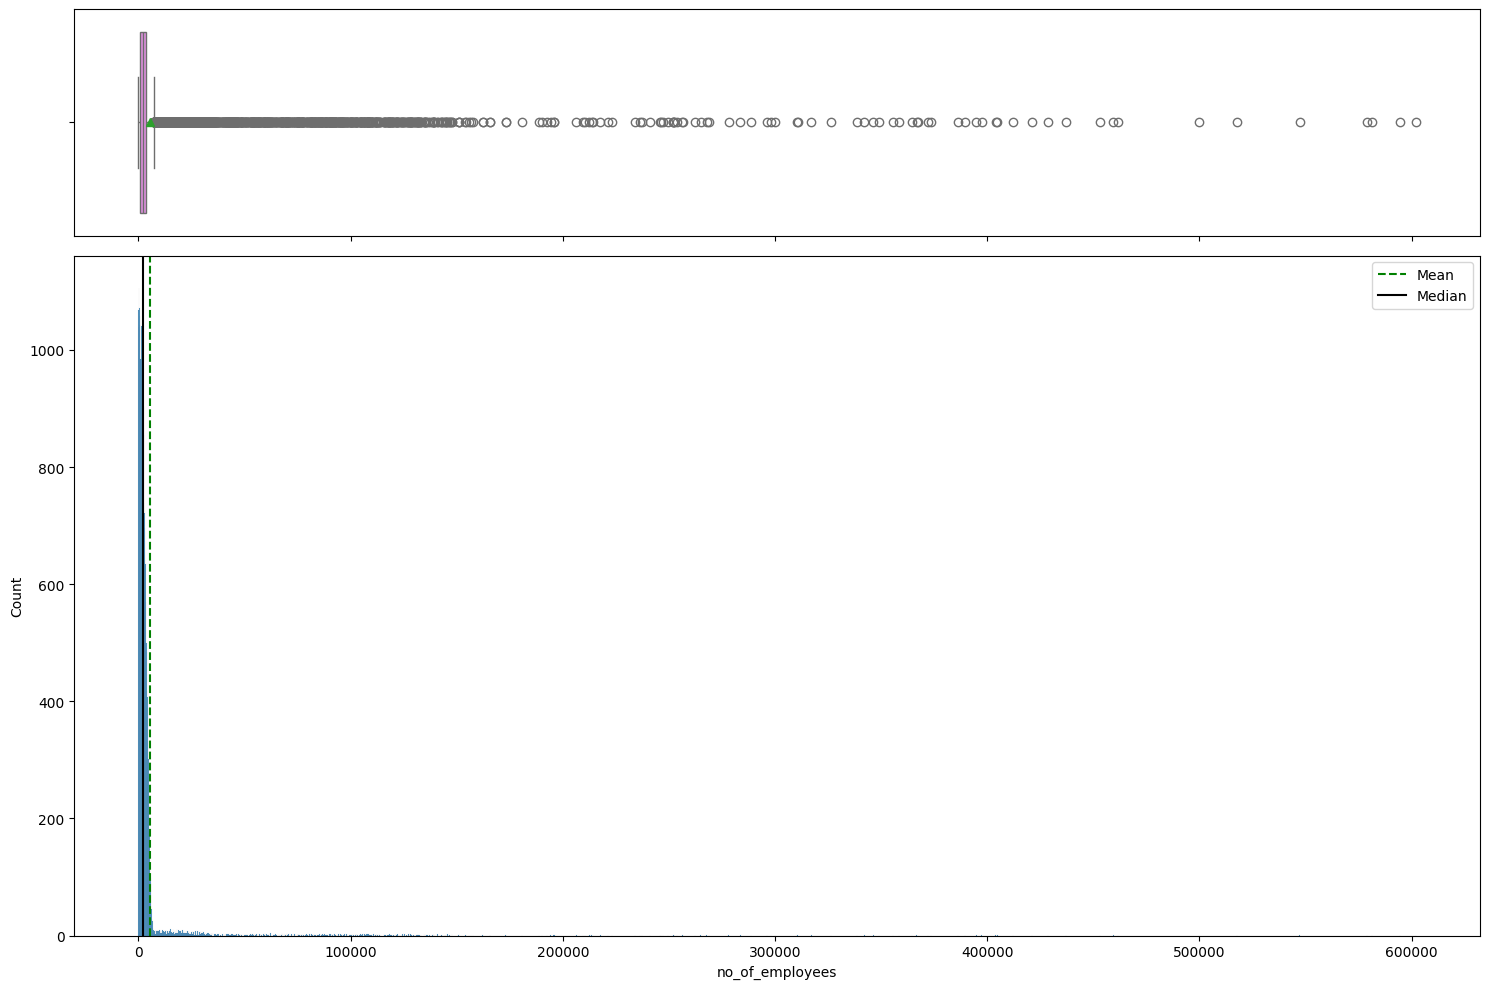

In [41]:
# Create a visualization that combines a histogram and boxplot for the 'no_of_employees' column
# This helps to understand the distribution of employee counts across the dataset
histogram_boxplot(data, "no_of_employees")

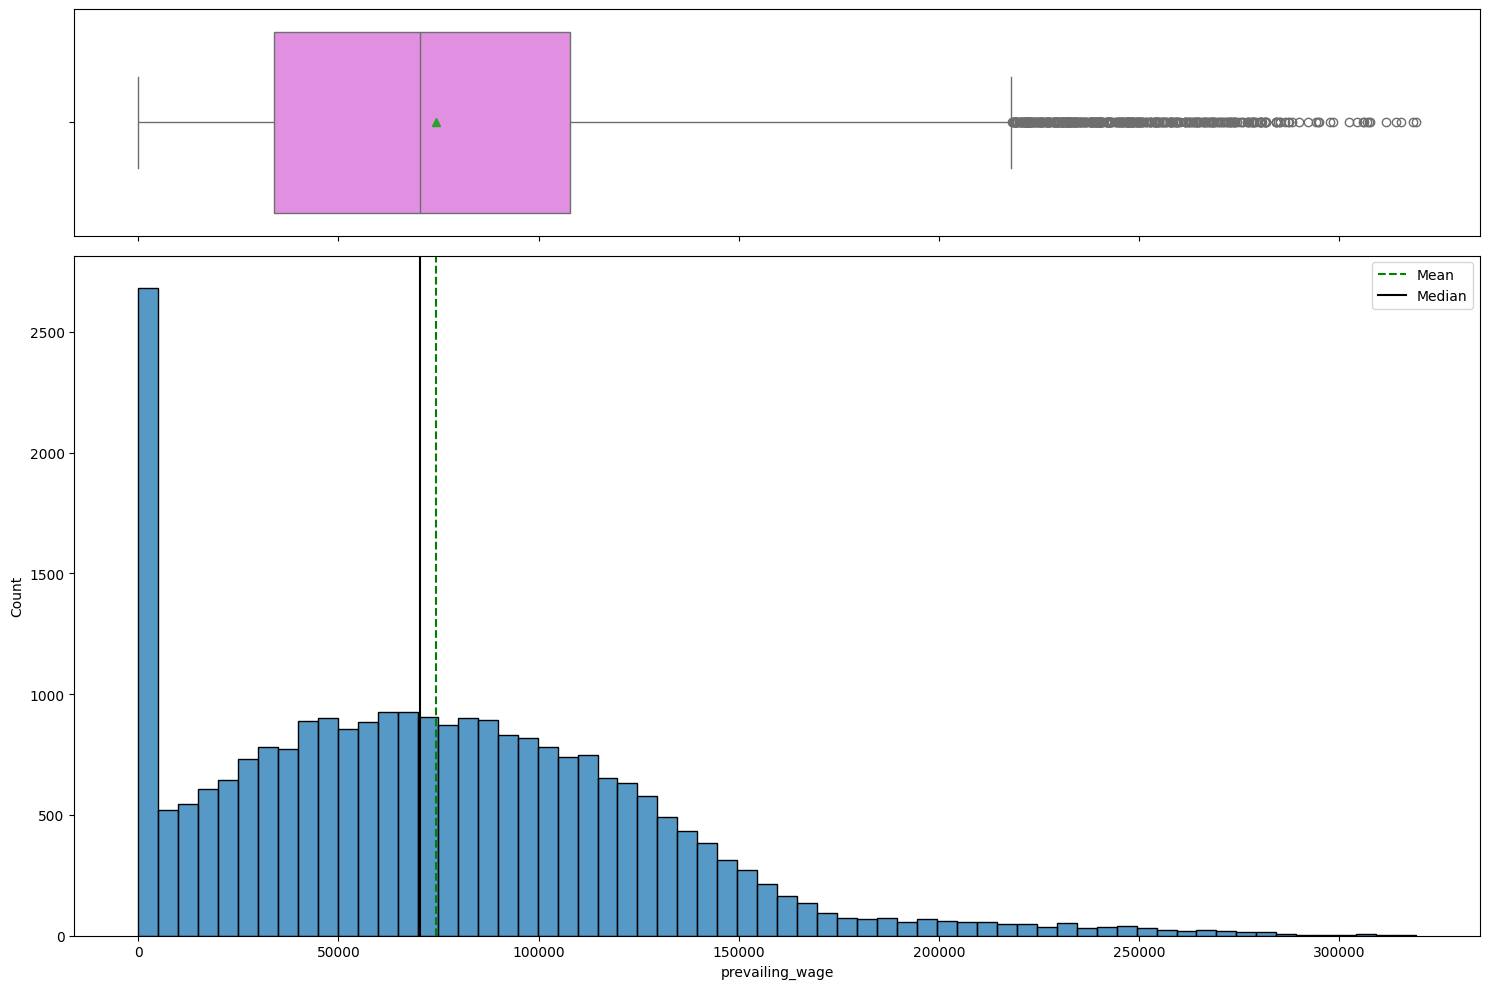

In [42]:
# Create a visualization that combines a histogram and boxplot for the 'prevailing_wage' column
# This helps to understand the distribution and identify potential outliers
histogram_boxplot(data,"prevailing_wage") 

In [43]:
# Count the frequency of each wage unit type for records where the prevailing wage is less than $100
# This helps identify how wages below $100 are typically measured (hourly, monthly, yearly, etc.)
data.loc[data["prevailing_wage"] < 100, "unit_of_wage"].value_counts() 

Hour    176
Name: unit_of_wage, dtype: int64

In [44]:
# Count the frequency of each wage unit type for records where the prevailing wage is less than $5000
# This helps identify how wages below $5000 are typically measured (hourly, monthly, yearly, etc.)
data.loc[data["prevailing_wage"] < 5000, "unit_of_wage"].value_counts() 

Hour     2157
Year      518
Week        4
Month       3
Name: unit_of_wage, dtype: int64

In [45]:
# The list of the numerical variables
num_var = data.select_dtypes(include=['int64','float64']).columns
print(num_var)

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')


In [46]:
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with counts or percentages and annotations on top.

    data: pandas DataFrame
    feature: column name for which to plot counts
    perc: bool, if True show percentages, else show counts
    n: top n categories to show (by count). If None, show all.
    """
    total = len(data[feature])
    value_counts = data[feature].value_counts()

    if n:
        value_counts = value_counts[:n]

    plt.figure(figsize=(max(6, len(value_counts)), 5))
    ax = sns.countplot(
        data=data,
        x=feature,
        order=value_counts.index,
        palette="Paired"
    )

    plt.xticks(rotation=90, fontsize=12)

    for p in ax.patches:
        height = p.get_height()
        if perc:
            label = "{:.1f}%".format(100 * height / total)
        else:
            label = f"{height}"

        ax.annotate(
            label,
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='center',
            fontsize=11,
            xytext=(0, 5),
            textcoords='offset points'
        )

    plt.tight_layout()
    plt.show()


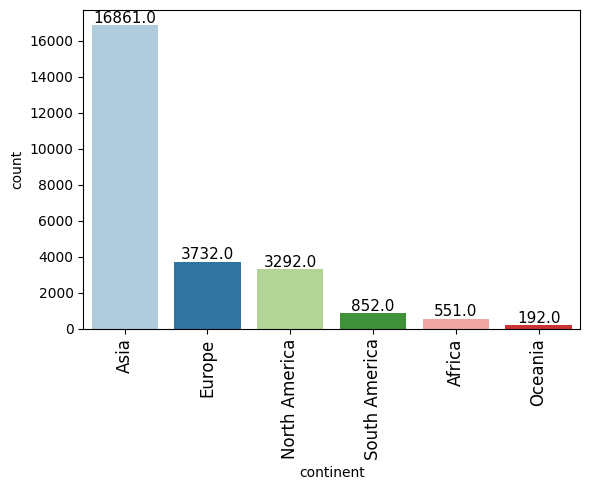

In [47]:
labeled_barplot(data, "continent") 

##### **Observations:**
- More than half of the employees are from Asia.

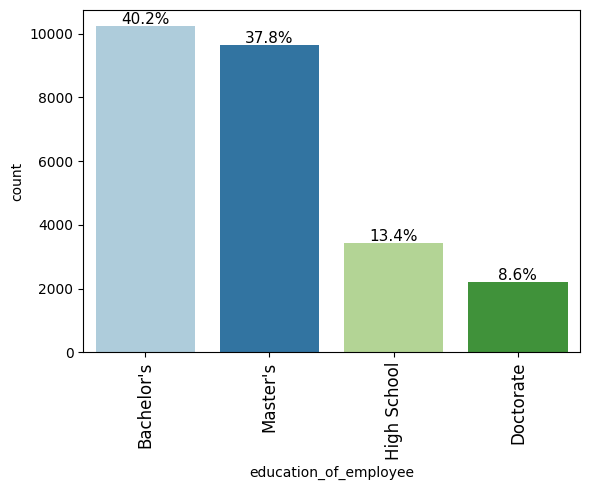

In [49]:
# Create a bar plot showing the distribution of employee education levels
# The perc=True parameter displays percentages instead of raw counts
labeled_barplot(data, "education_of_employee", perc=True)

#### Observations on education of employee
- 40.2% have Bachelor's degree
- 37.8% and 8.6% have Master's degree and Doctorate degree respectively.
- 13.4% are only High scholld graduates. 

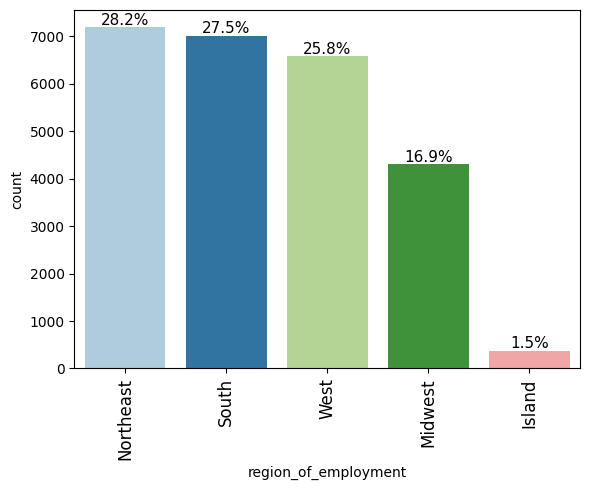

In [51]:
# Create a bar plot showing the percentage distribution of employees across different regions
# The function labeled_barplot() displays values on top of each bar and handles formatting
labeled_barplot(data, "region_of_employment", perc=True)

#### Observations on region of employment:
- Northeast and South aree the top two regions of employments.
- Island is hardly considered as intended region of employment in the US is only 1.5%
- Here, the island can be an outlier

#### Observations on job experience

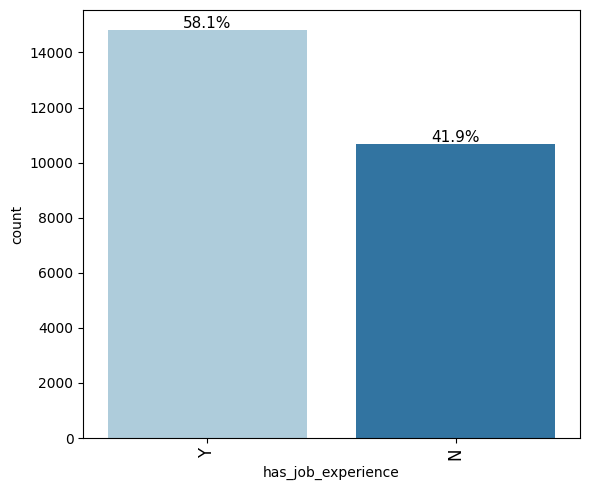

In [54]:
# Create a bar plot showing the distribution of job experience
# Parameter 'data' contains the dataset being analyzed
# Parameter "has_job_experience" specifies the column to visualize
labeled_barplot(data, "has_job_experience", perc=True)

#### Observations:
- 58.1% has some job experience 

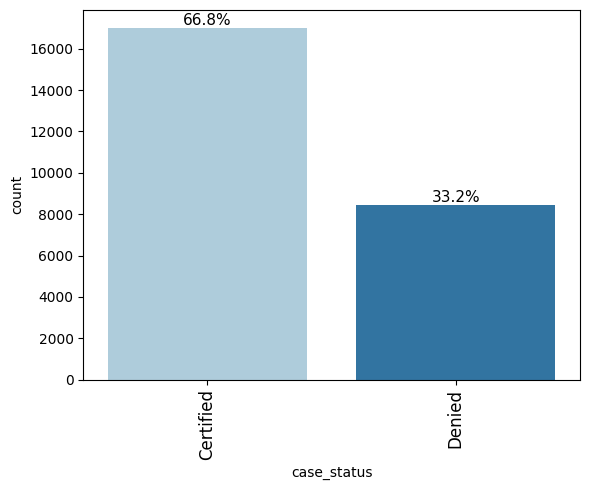

In [56]:
# Create a bar plot showing the distribution of visa applications by case status
labeled_barplot(data, "case_status", perc=True)

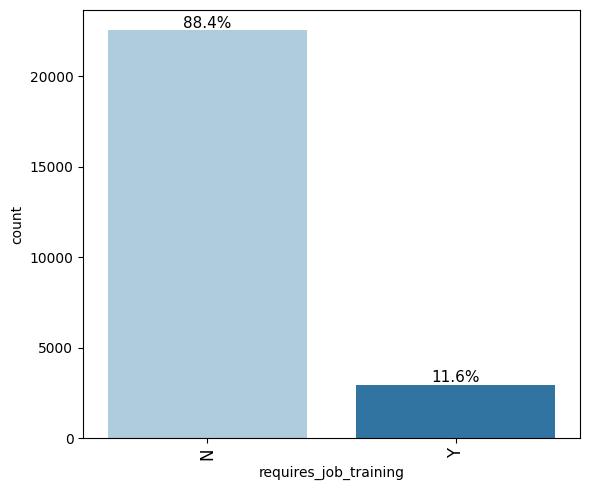

In [57]:
# Create a bar plot showing the percentage distribution of the 'requires_job_training' column
labeled_barplot(data, "requires_job_training", perc=True)

### Bivariate Analysis

#### Correlation Check

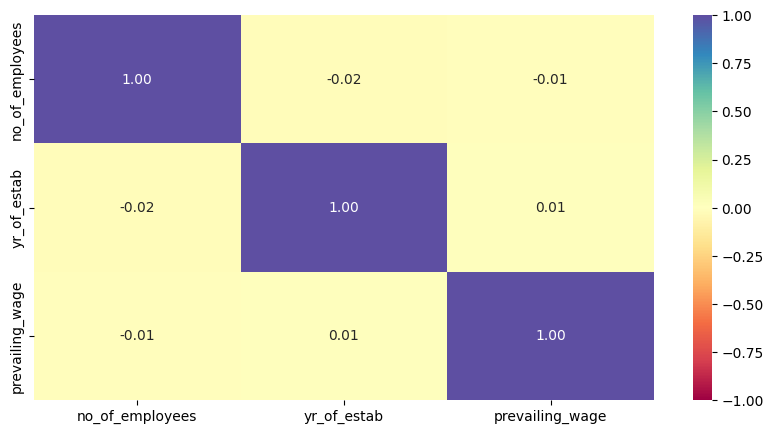

In [60]:
# Get a list of all numeric columns in the dataset
cols_list = data.select_dtypes(include=np.number).columns.tolist()

# Create a figure with specified size (width=10, height=5)
plt.figure(figsize=(10, 5))
# Generate a correlation heatmap for all numeric columns
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

##### **Observations:**
The correlation coefficient between the variables is very close to zero. 
This indicates that there is a weak correlation or almost no linear relationship between tthese variables.

**Creating functions that will help us with further analysis.**

In [63]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):
    """
    Creates a 2x2 grid of plots showing the distribution of a predictor variable with respect to a target variable.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        The dataset containing the predictor and target variables
    predictor : str
        The name of the predictor variable to analyze
    target : str
        The name of the target variable (must be binary)
    
    Returns:
    --------
    None - displays the plots
    """
    # Create a 2x2 grid of subplots
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    # Get unique values of the target variable
    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

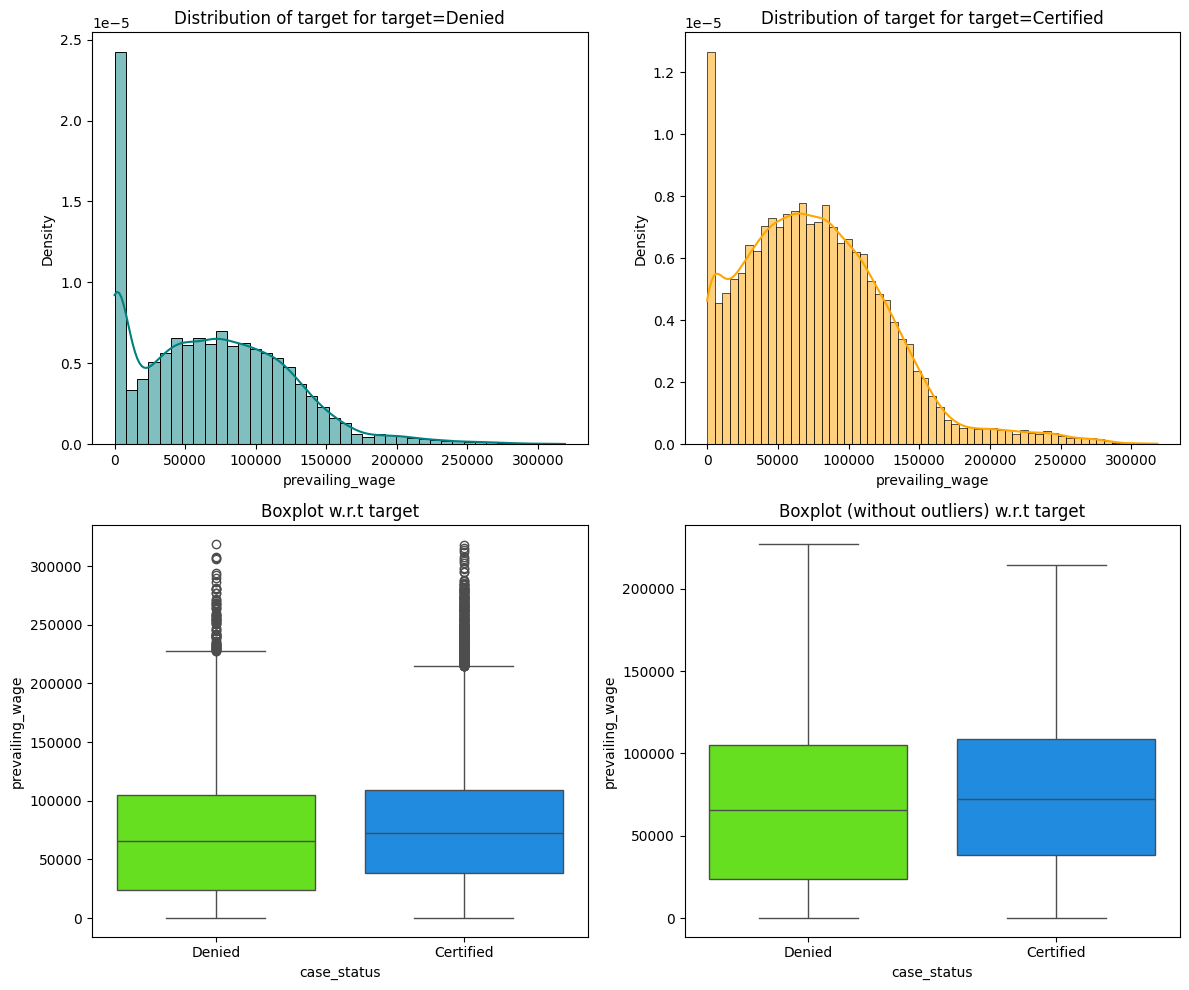

In [64]:
# Create a distribution plot to visualize the relationship between 'prevailing_wage' and 'case_status'
# This helps analyze how wage distributions differ across different case status categories
distribution_plot_wrt_target(data, "prevailing_wage", "case_status")

##### **Observations:**
The median prevailing wage for certified applications is marginally higher than for those that were denied.

In [66]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    # Count unique values in predictor column for figure sizing
    count = data[predictor].nunique()
    # Get the least frequent category in target variable to sort by
    sorter = data[target].value_counts().index[-1]
    # Create a cross-tabulation with counts and sort by the least frequent category
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    # Create a cross-tabulation with proportions (normalized by row)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    # Plot stacked bar chart with width adjusted based on category count
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    # Add legend (this line is redundant as it's overridden by the next line)
    plt.legend(
        loc="lower left", frameon=False,
    )
    # Position legend outside the plot for better visibility
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


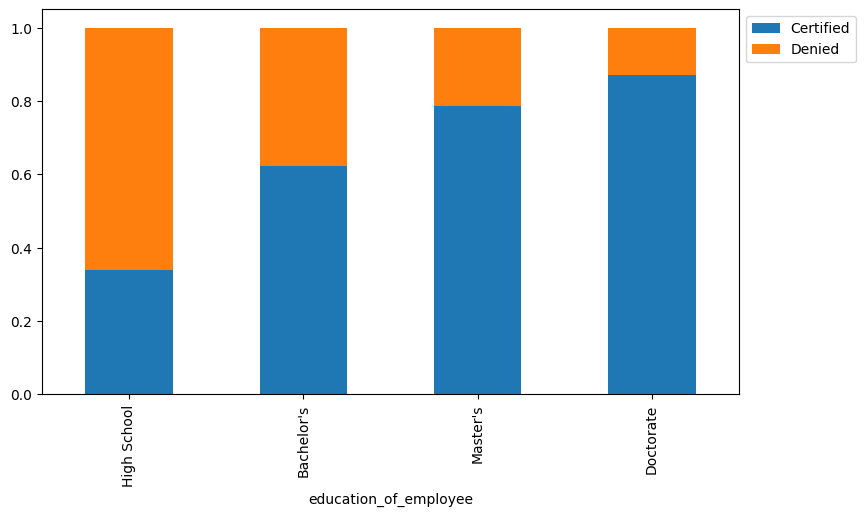

In [67]:
stacked_barplot(data, "education_of_employee", "case_status")

##### Observations:
Higher education does shows higher chances on getting VISA. 
More higher the education is more chances of getting VISA

#### How does visa status vary across different continents?

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


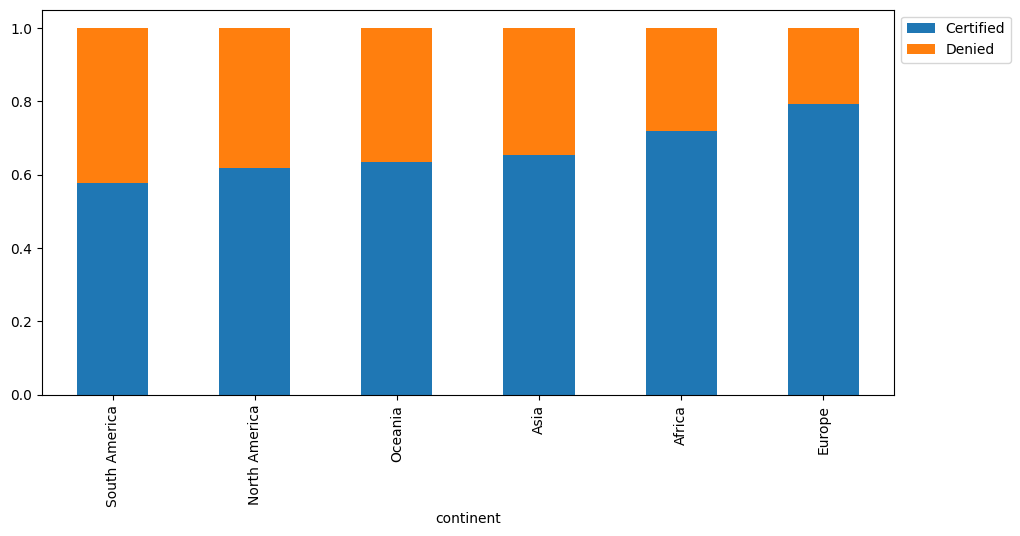

In [70]:
stacked_barplot(data, "continent", "case_status")

##### Observations:
Visa status varies significantly by continent, with Europe and Africa seeing higher approval rates.

#### Does having prior work experience influence the chances of visa certification for career opportunities abroad?

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


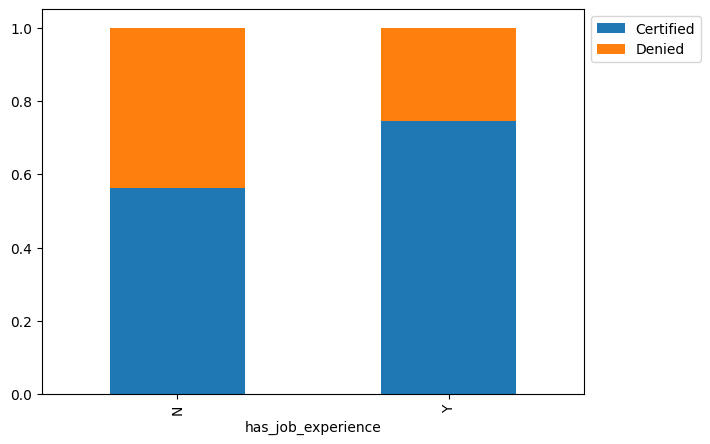

In [73]:
stacked_barplot(data, "has_job_experience", "case_status")

##### Observation: 
Yes, having job experience does impact visa case stattus significantly. 

#### Is the prevailing wage consistent across all regions of the US?

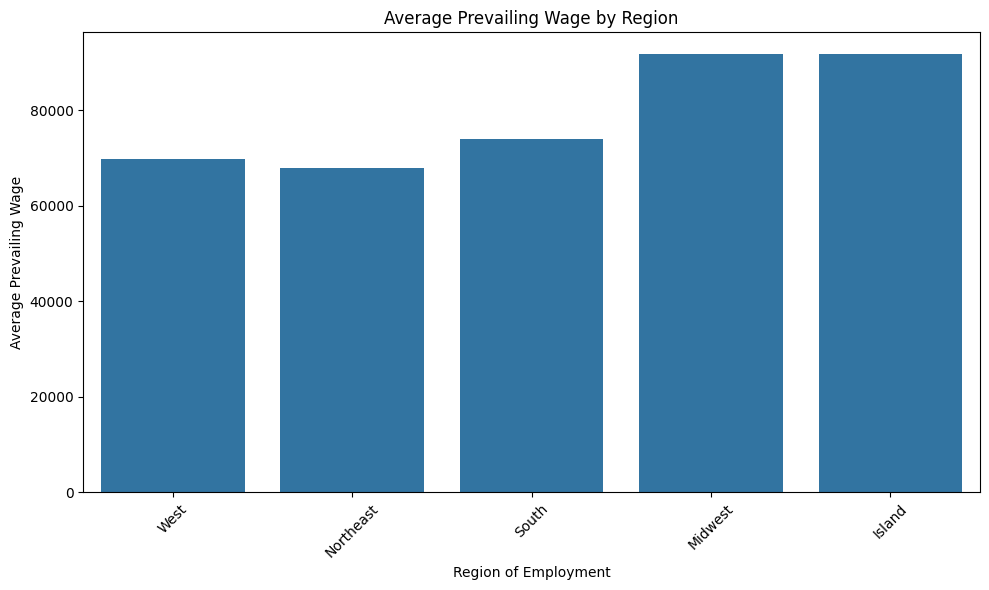

In [76]:
plt.figure(figsize=(10, 6))
sns.barplot(data=data, x='region_of_employment', y='prevailing_wage', estimator='mean', ci=None)
plt.title("Average Prevailing Wage by Region")
plt.xticks(rotation=45)
plt.ylabel("Average Prevailing Wage")
plt.xlabel("Region of Employment")
plt.tight_layout()
plt.show()

##### Observation: 
No, prevailing wages are not consistent across US regions. This regional disparity likely reflects differing labor markets, cost of living, and job demands.

#### Does visa status vary with changes in the prevailing wage set to protect both local talent and foreign workers?

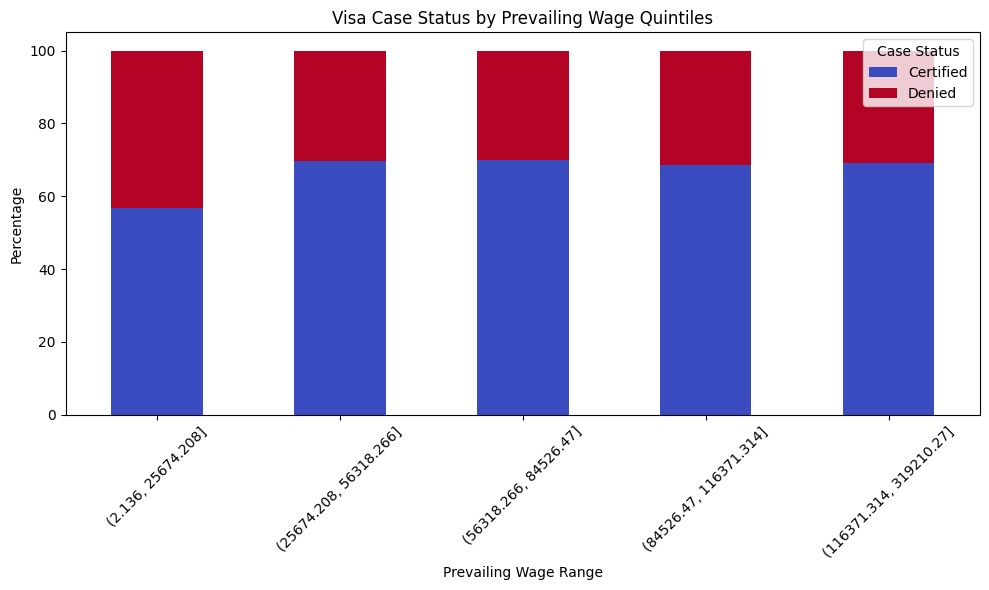

In [79]:
# Create wage bins
data['wage_bin'] = pd.qcut(data['prevailing_wage'], q=5, duplicates='drop')

# Cross-tabulate visa status by wage bin
wage_status_ct = pd.crosstab(data['wage_bin'], data['case_status'], normalize='index') * 100

# Plot
wage_status_ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='coolwarm')
plt.title("Visa Case Status by Prevailing Wage Quintiles")
plt.xlabel("Prevailing Wage Range")
plt.ylabel("Percentage")
plt.legend(title="Case Status")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Observation: 
Higher prevailing wages correlate with a higher likelihood of visa approval.

#### Does the unit of prevailing wage (Hourly, Weekly, etc.) have any impact on the likelihood of visa application certification?

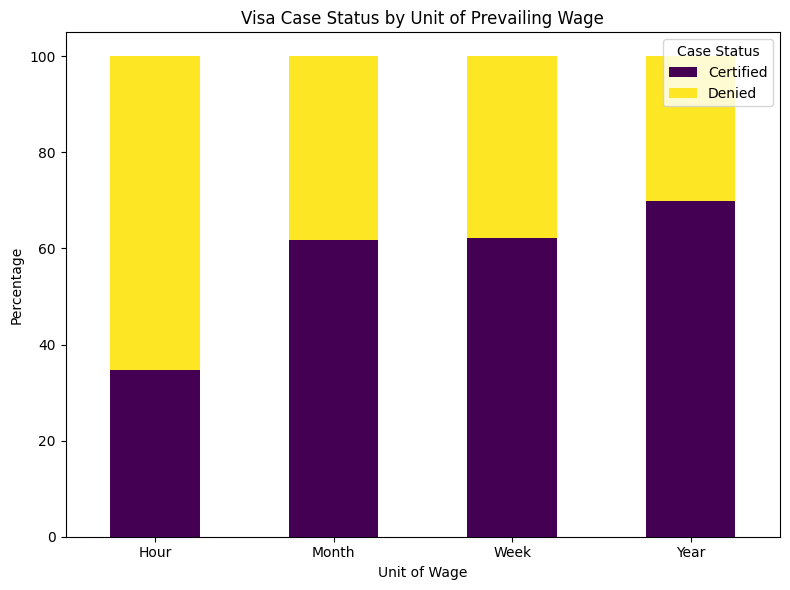

In [82]:
# Create a cross-tabulation: row = unit_of_wage, columns = case_status
unit_ct = pd.crosstab(data['unit_of_wage'], data['case_status'], normalize='index') * 100

# Plot it
unit_ct.plot(kind='bar', stacked=True, colormap='viridis', figsize=(8, 6))

plt.title("Visa Case Status by Unit of Prevailing Wage")
plt.xlabel("Unit of Wage")
plt.ylabel("Percentage")
plt.legend(title="Case Status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### Observation: 
The unit in which the prevailing wage is offered significantly correlates with visa approval likelihood — with Yearly wages showing the most favorable outcomes.

- Yearly wage cases have the highest approval rate.
- Hourly wage applications face the highest rejection rate, possibly due to associations with low-wage or part-time roles.
- This suggests that visa officers may favor roles that are:
    - Full-time
    - Long-term
    - Better compensated on an annual basis

##### Key observations from the Overall Bivarient plots: 

    Education of Employee
        - Master’s and Bachelor’s degree holders are the most common applicants.
        - Certification rate is higher among Master’s degree holders.

    Job Experience
        - Applicants with prior job experience have higher certification rates.
        - Lack of experience significantly correlates with denial.

    Full-time Position
        - Full-time roles are strongly associated with certified outcomes.
        - Part-time applications are more frequently denied.

    Region of Employment
        - Most cases are from West and Northeast.
        - Certification rates are fairly consistent across regions, but volume varies.

    Continent
        - Asia and North America dominate the applicant pool.
        - North American applicants enjoy a noticeably higher approval rate.
        

These insights suggest the following features might be strong drivers of approval:
        - ducation level
        - Job experience
        - Full-time vs part-time status
        - Geographic origin (continent)

## Data Pre-processing

### Outlier Check

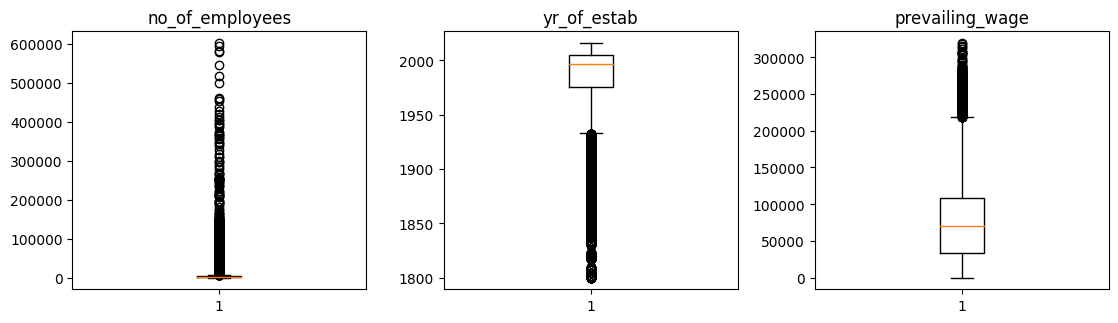

In [87]:
# outlier detection using boxplot
# Get a list of all numeric columns in the dataset
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

# Create a figure with appropriate size for multiple subplots
plt.figure(figsize=(15, 12))

# Loop through each numeric column and create a boxplo$t
for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

#### **Observations:**
1. Number of Employees
    - Most employers have small to mid-sized workforces (median well below 10,000), but a handful of “mega-employers” report hundreds of thousands of employees.
    - Those extreme outliers risk skewing model training—consider capping at a reasonable percentile or applying a log transformation.

2. Year of Establishment
    - The bulk of companies were founded between 1980 and 2020, with a median founding year around 2000.
    - A distinct cluster of “founding years” near 1800–1820 appears implausible (likely placeholder or data-entry errors). These should be investigated and either corrected or removed.

3. Prevailing Wage
    - The interquartile range of annualized wages sits roughly between USD 30,000 and USD 115,000, with a median near USD 70,000.
    - There are notable high-end outliers (wages above USD 200,000), likely reflecting executive or highly specialized roles.


### Data Preparation for modeling

- Our objective is to predict which visa applications are likely to be certified.
- Before building the model, we need to encode the categorical features to prepare the data for machine learning algorithms.
- We will then split the dataset into training and test sets to effectively evaluate the model's performance on unseen data.

In [90]:
# Convert target to binary
data["case_status"] = data["case_status"].apply(lambda x: 1 if x == "Certified" else 0)

# Split features and target
X = data.drop(['case_status'], axis=1)  # Drop the target column
y = data["case_status"]

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Split into train and validation (70% train, 30% val+test)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

# Split validation further into validation and test (90% val, 10% test)
X_val, X_test, y_val, y_test = train_test_split(
    X_val, y_val, test_size=1/10, random_state=1, stratify=y_val
)

In [91]:
print("Shape of Training set : ", X_train.shape)
print("Shape of Validation set : ", X_val.shape)
print("Shape of Test set : ", X_test.shape)

print("\nPercentage of classes in Training set:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nPercentage of classes in Validation set:")
print((y_val.value_counts(normalize=True) * 100).round(2))

print("\nPercentage of classes in Test set:")
print((y_test.value_counts(normalize=True) * 100).round(2))


Shape of Training set :  (17836, 25)
Shape of Validation set :  (6879, 25)
Shape of Test set :  (765, 25)

Percentage of classes in Training set:
1    66.79
0    33.21
Name: case_status, dtype: float64

Percentage of classes in Validation set:
1    66.78
0    33.22
Name: case_status, dtype: float64

Percentage of classes in Test set:
1    66.8
0    33.2
Name: case_status, dtype: float64


## Model Building

### Model Evaluation Criterion

Primary Metric: F1 Score

Why F1 Score?

The F1 Score is the harmonic mean of Precision and Recall, and is especially useful when:
    - There is class imbalance (as in our dataset: Certified ≈ 67%, Denied ≈ 33%).
    - Both false positives (wrongly certifying a weak case) and false negatives (denying a strong applicant) have serious business implications.


Metric Rationale:
- Accuracy: Can be misleading when one class dominates (e.g., high accuracy just by predicting "Certified" for all)
- Precision: Important if false approvals (visa misuse) must be minimized
- Recall:Important if we aim to avoid missing good candidates
- F1 Score: Balances both precision and recall — ideal for our use case


We select the F1 Score as our primary evaluation metric because it provides a balanced assessment of model performance in the presence of class imbalance and aligns with the business goal of reducing both wrongful certifications and denials.

First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.
* The `model_performance_classification_sklearn` function will be used to check the model performance of models.
* The `confusion_matrix_sklearn` function will be used to plot the confusion matrix.

In [96]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn

def model_performance_classification_sklearn(model, predictors, target, average='binary'):
    """
    Function to compute Accuracy, Recall, Precision, and F1-Score for classification models.

    model: trained classifier
    predictors: feature set
    target: actual target values
    average: averaging method for multiclass (default is 'binary')
    """
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred, average=average)
    precision = precision_score(target, pred, average=average)
    f1 = f1_score(target, pred, average=average)

    df_perf = pd.DataFrame(
        {"Accuracy": [acc], "Recall": [recall], "Precision": [precision], "F1": [f1]}
    )

    return df_perf

In [97]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    Plots a confusion matrix with percentage annotations.

    Parameters:
    model: Trained classifier
    predictors: Feature matrix
    target: True labels
    """
    from sklearn.metrics import confusion_matrix
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)

    labels = np.asarray([
        f"{item}\n{item/cm.sum():.2%}" for item in cm.flatten()
    ]).reshape(cm.shape)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.title("Confusion Matrix with Percentages")
    plt.tight_layout()
    plt.show()

In [98]:
# remove or replace invalid characters in all of your feature‐set column names
import re

def clean_column_names(cols):
    # replace any '[', ']', '<', '>' with underscore or drop them altogether
    return [re.sub(r"[\[\]<>]", "_", c) for c in cols]

# apply to train, val, test
X_train.columns = clean_column_names(X_train.columns)
X_val.columns   = clean_column_names(X_val.columns)
X_test.columns  = clean_column_names(X_test.columns)

# now XGB will happily accept the feature names
xgb = XGBClassifier(random_state=1, eval_metric="logloss", use_label_encoder=False)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

In [99]:
# Train and store performance for all base models


# Decision Tree Classifier
dtree = DecisionTreeClassifier(random_state=1)  # Initialize decision tree with fixed random state for reproducibility
dtree.fit(X_train, y_train)  # Train the model on training data
dtree_model_train_perf = model_performance_classification_sklearn(dtree, X_train, y_train)  # Evaluate on training data
dtree_model_test_perf = model_performance_classification_sklearn(dtree, X_val, y_val)  # Evaluate on validation data

# Bagging Classifier
bagging = BaggingClassifier(random_state=1)  # Initialize bagging ensemble with fixed random state
bagging.fit(X_train, y_train)  # Train the bagging model
bagging_model_train_perf = model_performance_classification_sklearn(bagging, X_train, y_train)  # Evaluate on training data
bagging_model_test_perf = model_performance_classification_sklearn(bagging, X_val, y_val)  # Evaluate on validation data

# Random Forest Classifier
rf = RandomForestClassifier(random_state=1)  # Initialize random forest with fixed random state
rf.fit(X_train, y_train)  # Train the random forest model
rf_model_train_perf = model_performance_classification_sklearn(rf, X_train, y_train)  # Evaluate on training data
rf_model_test_perf = model_performance_classification_sklearn(rf, X_val, y_val)  # Evaluate on validation data

# AdaBoost Classifier
ab = AdaBoostClassifier(algorithm="SAMME", random_state=1)  # Initialize AdaBoost with SAMME algorithm
ab.fit(X_train, y_train)  # Train the AdaBoost model
ab_classifier_model_train_perf = model_performance_classification_sklearn(ab, X_train, y_train)  # Evaluate on training data
ab_classifier_model_test_perf = model_performance_classification_sklearn(ab, X_val, y_val)  # Evaluate on validation data

# Gradient Boosting Classifier
gbc = GradientBoostingClassifier(random_state=1)  # Initialize gradient boosting with fixed random state
gbc.fit(X_train, y_train)  # Train the gradient boosting model
gbc_classifier_model_train_perf = model_performance_classification_sklearn(gbc, X_train, y_train)  # Evaluate on training data
gbc_classifier_model_test_perf = model_performance_classification_sklearn(gbc, X_val, y_val)  # Evaluate on validation data

# XGBoost Classifier
xgb = XGBClassifier(random_state=1, eval_metric="logloss", use_label_encoder=False)  # Initialize XGBoost with logloss metric
xgb.fit(X_train, y_train)  # Train the XGBoost model
xgb_classifier_model_train_perf = model_performance_classification_sklearn(xgb, X_train, y_train)  # Evaluate on training data
xgb_classifier_model_test_perf = model_performance_classification_sklearn(xgb, X_val, y_val)  # Evaluate on validation data


#### Defining scorer to be used for cross-validation and hyperparameter tuning

In [101]:
# Define F1 scorer
# For binary classification
scorer = metrics.make_scorer(metrics.f1_score, average='binary') # Define the metric

# For multiclass
# scorer = metrics.make_scorer(metrics.f1_score, average='weighted')

**We are now done with pre-processing and evaluation criterion, so let's start building the model.**

### Model building with Original data

In [104]:
from sklearn.metrics import f1_score, make_scorer

warnings.filterwarnings("ignore")  # Optional: suppress xgboost warnings

def clean_column_names(df):
    """Clean column names to be compatible with XGBoost."""
    df.columns = df.columns.astype(str).str.replace(r"[\[\]<>]", "_", regex=True)
    return df

def evaluate_models(X_train, y_train, X_val, y_val, average='binary'):
    """
    Evaluate multiple classifiers using F1 score with cross-validation and validation set.

    Returns:
    - cv_results_dict: dict of model name -> mean CV score
    - val_scores_dict: dict of model name -> validation F1 score
    - fitted_models: dict of model name -> trained model
    """
    # Clean column names for XGBoost compatibility
    X_train = clean_column_names(X_train)
    X_val = clean_column_names(X_val)

    scorer = make_scorer(f1_score, average=average)

    models = [
        ("Bagging", BaggingClassifier(random_state=1)),
        ("Random Forest", RandomForestClassifier(random_state=1)),
        ("Gradient Boosting", GradientBoostingClassifier(random_state=1)),
        ("Adaboost", AdaBoostClassifier(random_state=1)),
        ("XGBoost", XGBClassifier(random_state=1, eval_metric="logloss", use_label_encoder=False)),
        ("Decision Tree", DecisionTreeClassifier(random_state=1))
    ]

    cv_results_dict = {}
    val_scores_dict = {}
    fitted_models = {}

    print("\nCross-Validation Performance (F1 Score):\n")

    for name, model in models:
        kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
        cv_score = cross_val_score(model, X_train, y_train, scoring=scorer, cv=kfold)
        cv_mean = cv_score.mean()
        cv_results_dict[name] = cv_mean
        print(f"{name}: {cv_mean:.4f}")

    print("\nValidation Performance (F1 Score):\n")

    for name, model in models:
        model.fit(X_train, y_train)
        pred = model.predict(X_val)
        val_f1 = f1_score(y_val, pred, average=average)
        val_scores_dict[name] = val_f1
        fitted_models[name] = model
        print(f"{name}: {val_f1:.4f}")

    return cv_results_dict, val_scores_dict, fitted_models


# Sample usage
cv_scores, val_scores, models = evaluate_models(X_train, y_train, X_val, y_val)

# Identify best model by validation score
best_model = max(val_scores, key=val_scores.get)
print("\nBest model on validation set:", best_model)


Cross-Validation Performance (F1 Score):

Bagging: 0.7745
Random Forest: 0.8022
Gradient Boosting: 0.8230
Adaboost: 0.8179
XGBoost: 0.8100
Decision Tree: 0.7416

Validation Performance (F1 Score):

Bagging: 0.7722
Random Forest: 0.7999
Gradient Boosting: 0.8192
Adaboost: 0.8147
XGBoost: 0.8057
Decision Tree: 0.7459

Best model on validation set: Gradient Boosting


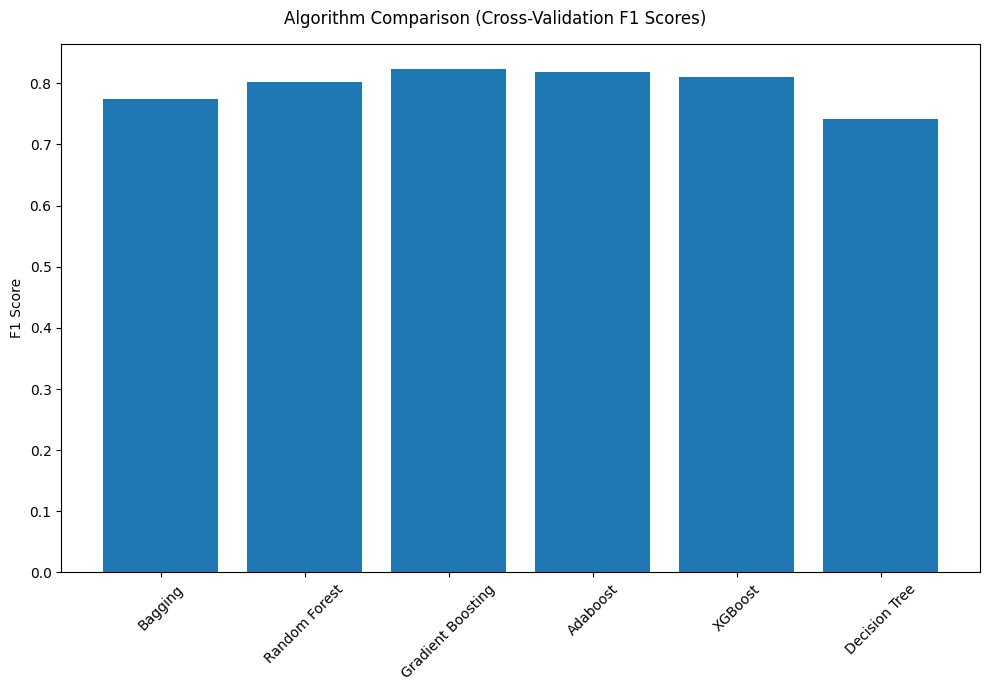

In [105]:
# Plotting boxplots for CV scores of all models

# Convert cv_scores (dict of model name -> mean score list) to a boxplot-compatible structure
fig = plt.figure(figsize=(10, 7))
fig.suptitle("Algorithm Comparison (Cross-Validation F1 Scores)")
ax = fig.add_subplot(111)

# For mean-only results:
plt.bar(cv_scores.keys(), cv_scores.values())

ax.set_ylabel("F1 Score")
ax.set_xticklabels(cv_scores.keys(), rotation=45)
plt.tight_layout()
plt.show()

### Model Building with Oversampled data

In [107]:
from imblearn.over_sampling import SMOTE

print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=1)  # k_neighbors usually set to 5
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

print("After OverSampling, counts of label '1': {}".format(sum(y_train_over == 1)))
print("After OverSampling, counts of label '0': {} \n".format(sum(y_train_over == 0)))

print("After OverSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After OverSampling, the shape of train_y: {} \n".format(y_train_over.shape))


Before OverSampling, counts of label '1': 11913
Before OverSampling, counts of label '0': 5923 

After OverSampling, counts of label '1': 11913
After OverSampling, counts of label '0': 11913 

After OverSampling, the shape of train_X: (23826, 25)
After OverSampling, the shape of train_y: (23826,) 



In [108]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss", use_label_encoder=False)))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models

print("\nCross-Validation performance on oversampled training dataset:\n")

for name, model in models:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)  # 5-fold cross-validation
    cv_result = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over, scoring=scorer, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {:.4f}".format(name, cv_result.mean()))

print("\nValidation Performance on original validation set:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)  # Fit on oversampled training data

    # Change the scoring metric below as needed
    scores = f1_score(y_val, model.predict(X_val))  # Using F1 score for validation
    # scores = precision_score(y_val, model.predict(X_val))

    print("{}: {:.4f}".format(name, scores))


Cross-Validation performance on oversampled training dataset:

Bagging: 0.7645
Random forest: 0.7897
GBM: 0.8000
Adaboost: 0.7854
Xgboost: 0.7962
dtree: 0.7298

Validation Performance on original validation set:

Bagging: 0.7606
Random forest: 0.7891
GBM: 0.8015
Adaboost: 0.7846
Xgboost: 0.7962
dtree: 0.7404


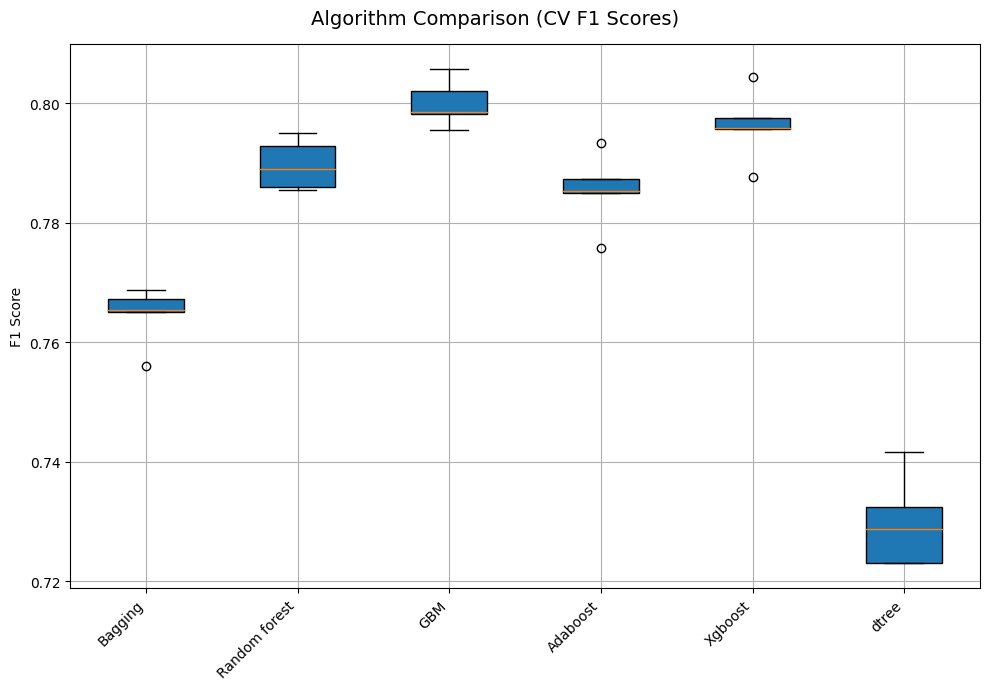

In [109]:
# Plotting boxplots for CV scores of all models
fig = plt.figure(figsize=(10, 7))
fig.suptitle("Algorithm Comparison (CV F1 Scores)", fontsize=14)

ax = fig.add_subplot(111)
ax.boxplot(results1, patch_artist=True)

ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_ylabel("F1 Score")
ax.grid(True)

plt.tight_layout()
plt.show()


### Model Building with Undersampled data

In [111]:
# Apply Random Undersampling
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

# Print class distribution before undersampling
print("Before UnderSampling, counts of label '1':", sum(y_train == 1))
print("Before UnderSampling, counts of label '0':", sum(y_train == 0), "\n")

# Print class distribution after undersampling
print("After UnderSampling, counts of label '1':", sum(y_train_un == 1))
print("After UnderSampling, counts of label '0':", sum(y_train_un == 0), "\n")

# Print shape of undersampled data
print("After UnderSampling, the shape of train_X:", X_train_un.shape)
print("After UnderSampling, the shape of train_y:", y_train_un.shape, "\n")


Before UnderSampling, counts of label '1': 11913
Before UnderSampling, counts of label '0': 5923 

After UnderSampling, counts of label '1': 5923
After UnderSampling, counts of label '0': 5923 

After UnderSampling, the shape of train_X: (11846, 25)
After UnderSampling, the shape of train_y: (11846,) 



In [112]:
# # Define the F1 scorer
# scorer = make_scorer(f1_score)

# List of models
models = []
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(algorithm="SAMME", random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss", use_label_encoder=False)))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []
names = []

print("\nCross-Validation performance on undersampled training dataset:\n")

for name, model in models:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)  # using 5-fold CV
    cv_result = cross_val_score(
        estimator=model, X=X_train_un, y=y_train_un, scoring=scorer, cv=kfold, n_jobs=-1
    )
    results1.append(cv_result)
    names.append(name)
    print(f"{name}: {cv_result.mean():.4f}")

print("\nValidation Performance (F1 Score):\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)  # train on undersampled data
    scores = f1_score(y_val, model.predict(X_val))  # choose f1 as the metric
    print(f"{name}: {scores:.4f}")


Cross-Validation performance on undersampled training dataset:

Bagging: 0.6434
Random forest: 0.6817
GBM: 0.7141
Adaboost: 0.6949
Xgboost: 0.6905
dtree: 0.6253

Validation Performance (F1 Score):

Bagging: 0.6870
Random forest: 0.7302
GBM: 0.7612
Adaboost: 0.7604
Xgboost: 0.7429
dtree: 0.6801


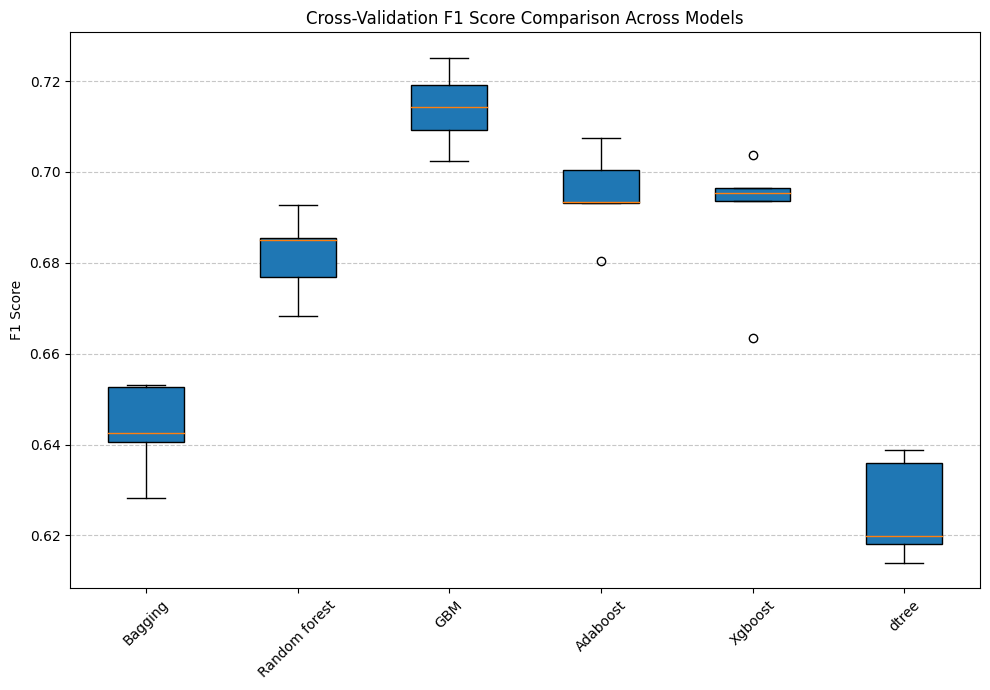

In [113]:
# Plotting boxplots for CV scores of all models defined above
plt.figure(figsize=(10, 7))
plt.title("Cross-Validation F1 Score Comparison Across Models")
plt.boxplot(results1, patch_artist=True)
plt.xticks(ticks=range(1, len(names) + 1), labels=names, rotation=45)
plt.ylabel("F1 Score")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### Compare training performance

In [115]:
# Compare training performance
models_train_comp_df = pd.concat(
    [
        dtree_model_train_perf.T,
        bagging_model_train_perf.T,
        rf_model_train_perf.T,
        ab_classifier_model_train_perf.T,
        gbc_classifier_model_train_perf.T,
        xgb_classifier_model_train_perf.T
    ],
    axis=1
)

models_train_comp_df.columns = [
    "Decision Tree",
    "Bagging",
    "Random Forest",
    "Adaboost",
    "Gradient Boosting",
    "XGBoost"
]

models_train_comp_df = models_train_comp_df

print("Training performance comparison of base models:")
display(models_train_comp_df)

# Compare test performance
models_test_comp_df = pd.concat(
    [
        dtree_model_test_perf.T,
        bagging_model_test_perf.T,
        rf_model_test_perf.T,
        ab_classifier_model_test_perf.T,
        gbc_classifier_model_test_perf.T,
        xgb_classifier_model_test_perf.T
    ],
    axis=1
)

models_test_comp_df.columns = [
    "Decision Tree",
    "Bagging",
    "Random Forest",
    "Adaboost",
    "Gradient Boosting",
    "XGBoost"
]

models_test_comp_df = models_test_comp_df

print("Testing performance comparison of base models:")
display(models_test_comp_df)


Training performance comparison of base models:


,Decision Tree,Bagging,Random Forest,Adaboost,Gradient Boosting,XGBoost
Accuracy,1.0,0.984750,0.999944,0.739684,0.758971,0.840996
Recall,1.0,0.985814,0.999916,0.887350,0.883908,0.930832
Precision,1.0,0.991306,1.000000,0.762039,0.783133,0.846424
F1,1.0,0.988552,0.999958,0.819934,0.830474,0.886623


Testing performance comparison of base models:


,Decision Tree,Bagging,Random Forest,Adaboost,Gradient Boosting,XGBoost
Accuracy,0.661143,0.697921,0.720599,0.733682,0.742114,0.725396
Recall,0.744667,0.766870,0.836308,0.883108,0.874837,0.852634
Precision,0.747106,0.777704,0.766560,0.758034,0.770218,0.763697
F1,0.745885,0.772249,0.799917,0.815805,0.819201,0.805718


##### Observations:
- From Training data:
    - Decision Tree and Random Forest are memorizing the training data (overfitting).
    - Adaboost, GBM, and XGBoost are showing more realistic and generalizable performance on training data.
      
- From Testing data:
    - Best overall test performance: Gradient Boosting and Adaboost (highest F1 = 0.82).
    - Best recall: Adaboost (0.88) — ideal for imbalanced problems where recall matters more.
    - Most balanced: Gradient Boosting and XGBoost.
      
- Overall:
    - Decision Tree and Random Forest are overfitting and tuning may help to avoid overfitting.
    - Gradient Boosting and Adaboost are performing best out of the box.

Let's perform hyperparameter tuning to improve generalization and optimize F1 further.

## Hyperparameter Tuning

**Best practices for hyperparameter tuning in AdaBoost:**

`n_estimators`:

- Start with a specific number (50 is used in general) and increase in steps: 50, 75, 85, 100

- Use fewer estimators (e.g., 50 to 100) if using complex base learners (like deeper decision trees)

- Use more estimators (e.g., 100 to 150) when learning rate is low (e.g., 0.1 or lower)

- Avoid very high values unless performance keeps improving on validation

`learning_rate`:

- Common values to try: 1.0, 0.5, 0.1, 0.01

- Use 1.0 for faster training, suitable for fewer estimators

- Use 0.1 or 0.01 when using more estimators to improve generalization

- Avoid very small values (< 0.01) unless you plan to use many estimators (e.g., >500) and have sufficient data


---

Best parameters are {'n_estimators': 100, 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score = 0.7999

Training Performance:


,Accuracy,Recall,Precision,F1
0,0.796777,0.827499,0.779597,0.802834


Validation Performance:


,Accuracy,Recall,Precision,F1
0,0.731792,0.824989,0.784517,0.804244



Confusion Matrix - Training Data:


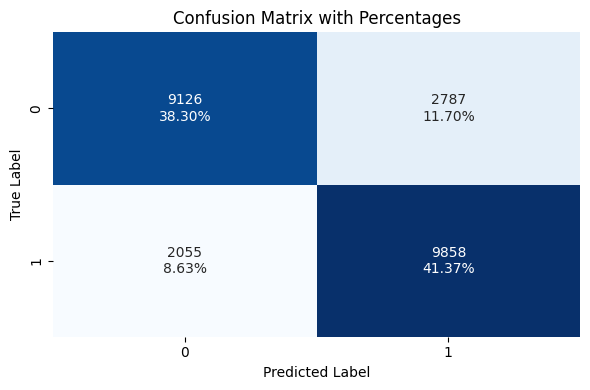


Confusion Matrix - Validation Data:


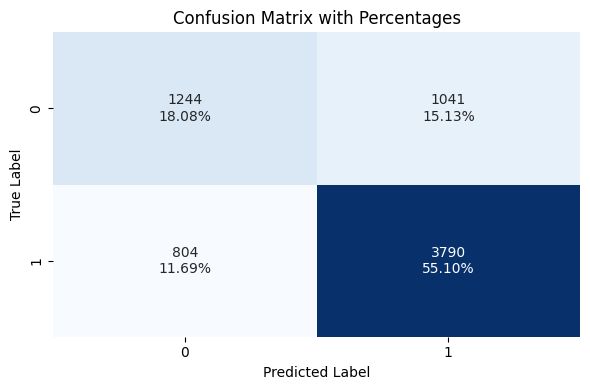

CPU times: user 7.58 s, sys: 351 ms, total: 7.93 s
Wall time: 1min 11s


In [119]:
%%time

# Define cross-validation strategy
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

# Define AdaBoost model
model = AdaBoostClassifier(random_state=1, algorithm="SAMME")

# Parameter grid for RandomizedSearchCV
param_grid = {
    "n_estimators": [50, 75, 85, 100],
    "learning_rate": [1.0, 0.5, 0.1, 0.01],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1)
    ]
}

# Run RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=-2,
    scoring=scorer,          
    cv=kfold,                # Use Stratified K-Fold
    random_state=1
)

# Fit on oversampled data
randomized_cv.fit(X_train_over, y_train_over)

# Show best parameters and score
print("Best parameters are {} with CV score = {:.4f}".format(
    randomized_cv.best_params_, randomized_cv.best_score_
))

# Evaluate best model
tuned_ada = randomized_cv.best_estimator_
tuned_ada.fit(X_train_over, y_train_over)

tuned_ada_train_perf = model_performance_classification_sklearn(tuned_ada, X_train_over, y_train_over)
print("\nTraining Performance:")
display(tuned_ada_train_perf)

tuned_ada_val_perf = model_performance_classification_sklearn(tuned_ada, X_val, y_val)
print("Validation Performance:")
display(tuned_ada_val_perf)

# Confusion Matrix on Training Data
print("\nConfusion Matrix - Training Data:")
confusion_matrix_sklearn(tuned_ada, X_train_over, y_train_over)

# Confusion Matrix on Validation Data
print("\nConfusion Matrix - Validation Data:")
confusion_matrix_sklearn(tuned_ada, X_val, y_val)

**Best practices for hyperparameter tuning in Random Forest:**


`n_estimators`:

* Start with a specific number (50 is used in general) and increase in steps: 50, 75, 100, 125
* Higher values generally improve performance but increase training time
* Use 100-150 for large datasets or when variance is high


`min_samples_leaf`:

* Try values like: 1, 2, 4, 5, 10
* Higher values reduce model complexity and help prevent overfitting
* Use 1–2 for low-bias models, higher (like 5 or 10) for more regularized models
* Works well in noisy datasets to smooth predictions


`max_features`:

* Try values: `"sqrt"` (default for classification), `"log2"`, `None`, or float values (e.g., `0.3`, `0.5`)
* `"sqrt"` balances between diversity and performance for classification tasks
* Lower values (e.g., `0.3`) increase tree diversity, reducing overfitting
* Higher values (closer to `1.0`) may capture more interactions but risk overfitting


`max_samples` (for bootstrap sampling):

* Try float values between `0.5` to `1.0` or fixed integers
* Use `0.6–0.9` to introduce randomness and reduce overfitting
* Smaller values increase diversity between trees, improving generalization

---

Best RF params: {'n_estimators': 125, 'min_samples_leaf': 10, 'max_samples': 0.7, 'max_features': 'sqrt'}
Best CV F1 score: 0.7188

Training performance:


,Accuracy,Recall,Precision,F1
0,0.76,0.78,0.74,0.76


Validation performance:


,Accuracy,Recall,Precision,F1
0,0.71,0.73,0.82,0.77



Confusion Matrix - Training Data:


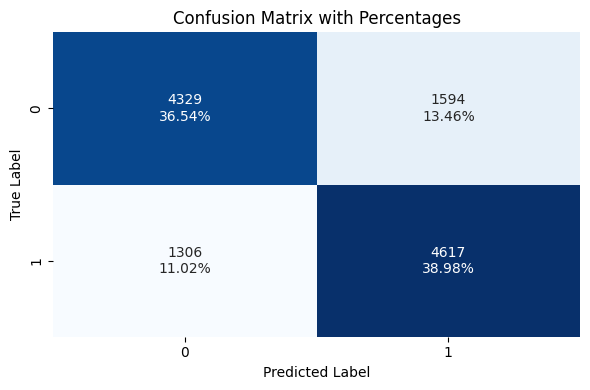


Confusion Matrix - Validation Data:


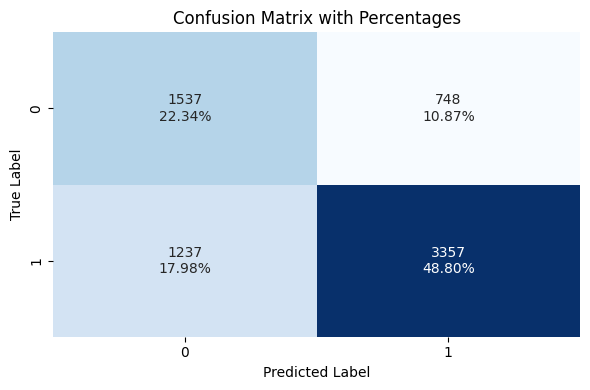

In [121]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

# Define base model
model = RandomForestClassifier(random_state=1)

# Hyperparameter grid
param_grid = {
    "n_estimators":      [50, 75, 100, 125],
    "min_samples_leaf":  [1, 2, 4, 5, 10],
    "max_features":      ["sqrt", "log2", 0.3, 0.5, None],
    "max_samples":       [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
}

# Scorer and CV
scorer = make_scorer(f1_score)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

# RandomizedSearchCV on undersampled data
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=-1,
    scoring=scorer,
    cv=cv,
    random_state=1
)
randomized_cv.fit(X_train_un, y_train_un)

# Extract the best estimator and retrain it on the same undersampled data
tuned_rf = randomized_cv.best_estimator_
tuned_rf.fit(X_train_un, y_train_un)

# Evaluate performance
tuned_rf_train_perf = model_performance_classification_sklearn(
    tuned_rf, X_train_un, y_train_un
)
tuned_rf_val_perf = model_performance_classification_sklearn(
    tuned_rf, X_val, y_val
)

print("Best RF params:", randomized_cv.best_params_)
print(f"Best CV F1 score: {randomized_cv.best_score_:.4f}\n")

print("Training performance:")
display(tuned_rf_train_perf.round(2))

print("Validation performance:")
display(tuned_rf_val_perf.round(2))

# Confusion matrices for the tuned Random Forest
print("\nConfusion Matrix - Training Data:")
confusion_matrix_sklearn(tuned_rf, X_train_un, y_train_un)

print("\nConfusion Matrix - Validation Data:")
confusion_matrix_sklearn(tuned_rf, X_val, y_val)


**Best practices for hyperparameter tuning in Gradient Boosting:**

`n_estimators`:

* Start with 100 (default) and increase: 100, 200, 300, 500
* Typically, higher values lead to better performance, but they also increase training time
* Use 200–500 for larger datasets or complex problems
* Monitor validation performance to avoid overfitting, as too many estimators can degrade generalization


`learning_rate`:

* Common values to try: 0.1, 0.05, 0.01, 0.005
* Use lower values (e.g., 0.01 or 0.005) if you are using many estimators (e.g., > 200)
* Higher learning rates (e.g., 0.1) can be used with fewer estimators for faster convergence
* Always balance the learning rate with `n_estimators` to prevent overfitting or underfitting


`subsample`:

* Common values: 0.7, 0.8, 0.9, 1.0
* Use a value between `0.7` and `0.9` for improved generalization by introducing randomness
* `1.0` uses the full dataset for each boosting round, potentially leading to overfitting
* Reducing `subsample` can help reduce overfitting, especially in smaller datasets


`max_features`:

* Common values: `"sqrt"`, `"log2"`, or float (e.g., `0.3`, `0.5`)
* `"sqrt"` (default) works well for classification tasks
* Lower values (e.g., `0.3`) help reduce overfitting by limiting the number of features considered at each split

---

Best parameters are {'subsample': 0.9, 'n_estimators': 500, 'max_features': 'sqrt', 'learning_rate': 0.05} with CV score = 0.8026

Training Performance:


,Accuracy,Recall,Precision,F1
0,0.80303,0.828842,0.788155,0.807987


Validation Performance:


,Accuracy,Recall,Precision,F1
0,0.727577,0.815629,0.784876,0.799957



Confusion Matrix - Validation Data:


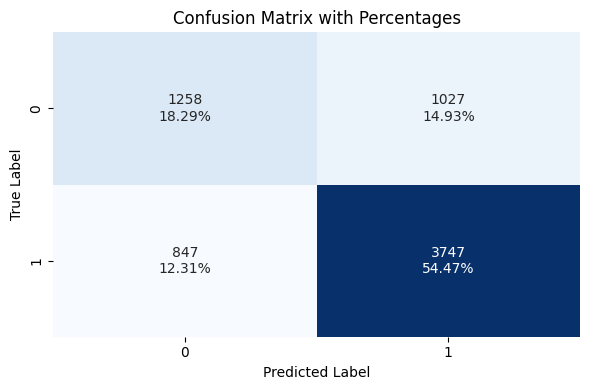

CPU times: user 5.93 s, sys: 464 ms, total: 6.39 s
Wall time: 2min 6s


In [123]:
%%time

# Define model
model = GradientBoostingClassifier(random_state=1)

# Define hyperparameter grid
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.1, 0.05, 0.01, 0.005],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "max_features": ["sqrt", "log2", 0.3, 0.5]
}

# Define Stratified K-Fold cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

# Set up randomized search
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=-2,
    scoring=scorer,
    cv=kfold,
    random_state=1
)

# Fit randomized search on oversampled data
randomized_cv.fit(X_train_over, y_train_over)

# Output best parameters and score
print("Best parameters are {} with CV score = {:.4f}".format(
    randomized_cv.best_params_, randomized_cv.best_score_
))

# Retrieve best model
tuned_gbm = randomized_cv.best_estimator_

# Training performance
tuned_gbm_train_perf = model_performance_classification_sklearn(
    tuned_gbm, X_train_over, y_train_over
)
print("\nTraining Performance:")
display(tuned_gbm_train_perf)

# Validation performance
tuned_gbm_val_perf = model_performance_classification_sklearn(
    tuned_gbm, X_val, y_val
)
print("Validation Performance:")
display(tuned_gbm_val_perf)

# Confusion Matrix
print("\nConfusion Matrix - Validation Data:")
confusion_matrix_sklearn(tuned_gbm, X_val, y_val)

**Best practices for hyperparameter tuning in XGBoost:**

`n_estimators`:

* Start with 50 and increase in steps: 50,75,100,125.
* Use more estimators (e.g., 150-250) when using lower learning rates
* Monitor validation performance
* High values improve learning but increase training time

`subsample`:

* Common values: 0.5, 0.7, 0.8, 1.0
* Use `0.7–0.9` to introduce randomness and reduce overfitting
* `1.0` uses the full dataset in each boosting round; may overfit on small datasets
* Values < 0.5 are rarely useful unless dataset is very large

`gamma`:

* Try values: 0 (default), 1, 3, 5, 8
* Controls minimum loss reduction needed for a split
* Higher values make the algorithm more conservative (i.e., fewer splits)
* Use values > 0 to regularize and reduce overfitting, especially on noisy data


`colsample_bytree`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled per tree
* Lower values (e.g., 0.3 or 0.5) increase randomness and improve generalization
* Use `1.0` when you want all features considered for every tree


`colsample_bylevel`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled at each tree level (i.e., per split depth)
* Lower values help in regularization and reducing overfitting
* Often used in combination with `colsample_bytree` for fine control over feature sampling

---

Tuned XGBoost Performance on Test Set:


,Accuracy,Recall,Precision,F1
0,0.742484,0.835616,0.790741,0.812559


Tuned XGBoost Performance on Training Set:


,Accuracy,Recall,Precision,F1
0,0.797994,0.820532,0.785141,0.802446



Tuned XGBoost Performance on Validation Set:


,Accuracy,Recall,Precision,F1
0,0.724233,0.810623,0.783835,0.797004



Confusion Matrix - Validation Data:


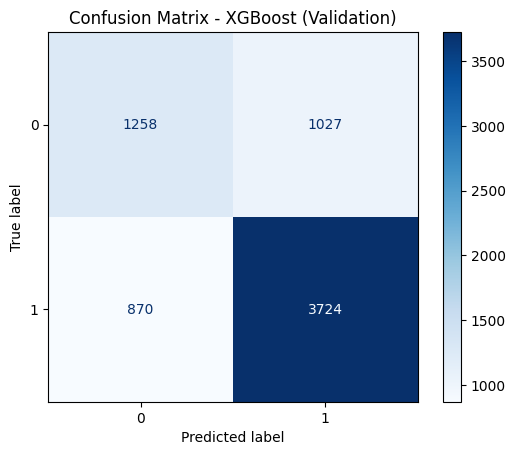

In [125]:
# Define model
model = XGBClassifier(random_state=1, eval_metric='logloss', use_label_encoder=False)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 75, 100, 125],
    'subsample': [0.5, 0.7, 0.8, 1.0],
    'gamma': [0, 1, 3, 5, 8],
    'colsample_bytree': [0.3, 0.5, 0.7, 1.0],
    'colsample_bylevel': [0.3, 0.5, 0.7, 1.0]
}

# Stratified K-Fold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

# Randomized Search
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=-2,
    scoring=scorer,
    cv=kfold,
    random_state=1
)

# Fit on oversampled training data
randomized_cv.fit(X_train_over, y_train_over)

# Get best estimator
tuned_xgb = randomized_cv.best_estimator_

# Align columns
train_columns = X_train.columns
X_val = X_val.reindex(columns=train_columns, fill_value=0)
X_test = X_test.reindex(columns=train_columns, fill_value=0)

# Evaluate performance
tuned_xgb_train_perf = model_performance_classification_sklearn(tuned_xgb, X_train_over, y_train_over)
tuned_xgb_val_perf = model_performance_classification_sklearn(tuned_xgb, X_val, y_val)
tuned_xgb_test_perf = model_performance_classification_sklearn(tuned_xgb, X_test, y_test)

# Display test performance
print("Tuned XGBoost Performance on Test Set:")
display(tuned_xgb_test_perf)

# Show train and val performance
tuned_xgb_train_perf, tuned_xgb_val_perf

# Display training performance
print("Tuned XGBoost Performance on Training Set:")
display(tuned_xgb_train_perf)

# Display validation performance
print("\nTuned XGBoost Performance on Validation Set:")
display(tuned_xgb_val_perf)

# Confusion matrix on validation data
print("\nConfusion Matrix - Validation Data:")
y_val_pred = tuned_xgb.predict(X_val)
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, display_labels=tuned_xgb.classes_, cmap="Blues")
plt.title("Confusion Matrix - XGBoost (Validation)")
plt.show()

## Model Performance Summary and Final Model Selection

In [127]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        tuned_gbm_train_perf.T,
        tuned_xgb_train_perf.T,
        tuned_ada_train_perf.T,
        tuned_rf_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient Boosting tuned with oversampled data",
    "XGBoost tuned with oversampled data", 
    "AdaBoost tuned with oversampled data",
    "Random forest tuned with undersampled data",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient Boosting tuned with oversampled data,XGBoost tuned with oversampled data,AdaBoost tuned with oversampled data,Random forest tuned with undersampled data
Accuracy,0.803030,0.797994,0.796777,0.755192
Recall,0.828842,0.820532,0.827499,0.779504
Precision,0.788155,0.785141,0.779597,0.743359
F1,0.807987,0.802446,0.802834,0.761002


In [128]:
# validation performance comparison

models_val_comp_df = pd.concat(
    [
        tuned_gbm_val_perf.T,
        tuned_xgb_val_perf.T, 
        tuned_ada_val_perf.T,
        tuned_rf_val_perf.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Gradient Boosting tuned with oversampled data",
    "XGBoost tuned with oversampled data", 
    "AdaBoost tuned with oversampled data",
    "Random forest tuned with undersampled data",
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Gradient Boosting tuned with oversampled data,XGBoost tuned with oversampled data,AdaBoost tuned with oversampled data,Random forest tuned with undersampled data
Accuracy,0.727577,0.724233,0.731792,0.711441
Recall,0.815629,0.810623,0.824989,0.730736
Precision,0.784876,0.783835,0.784517,0.817783
F1,0.799957,0.797004,0.804244,0.771813


In [129]:
# The final model 
final_model = tuned_gbm 

In [130]:
test = model_performance_classification_sklearn(final_model, X_test, y_test)
test

,Accuracy,Recall,Precision,F1
0,0.752941,0.849315,0.794872,0.821192


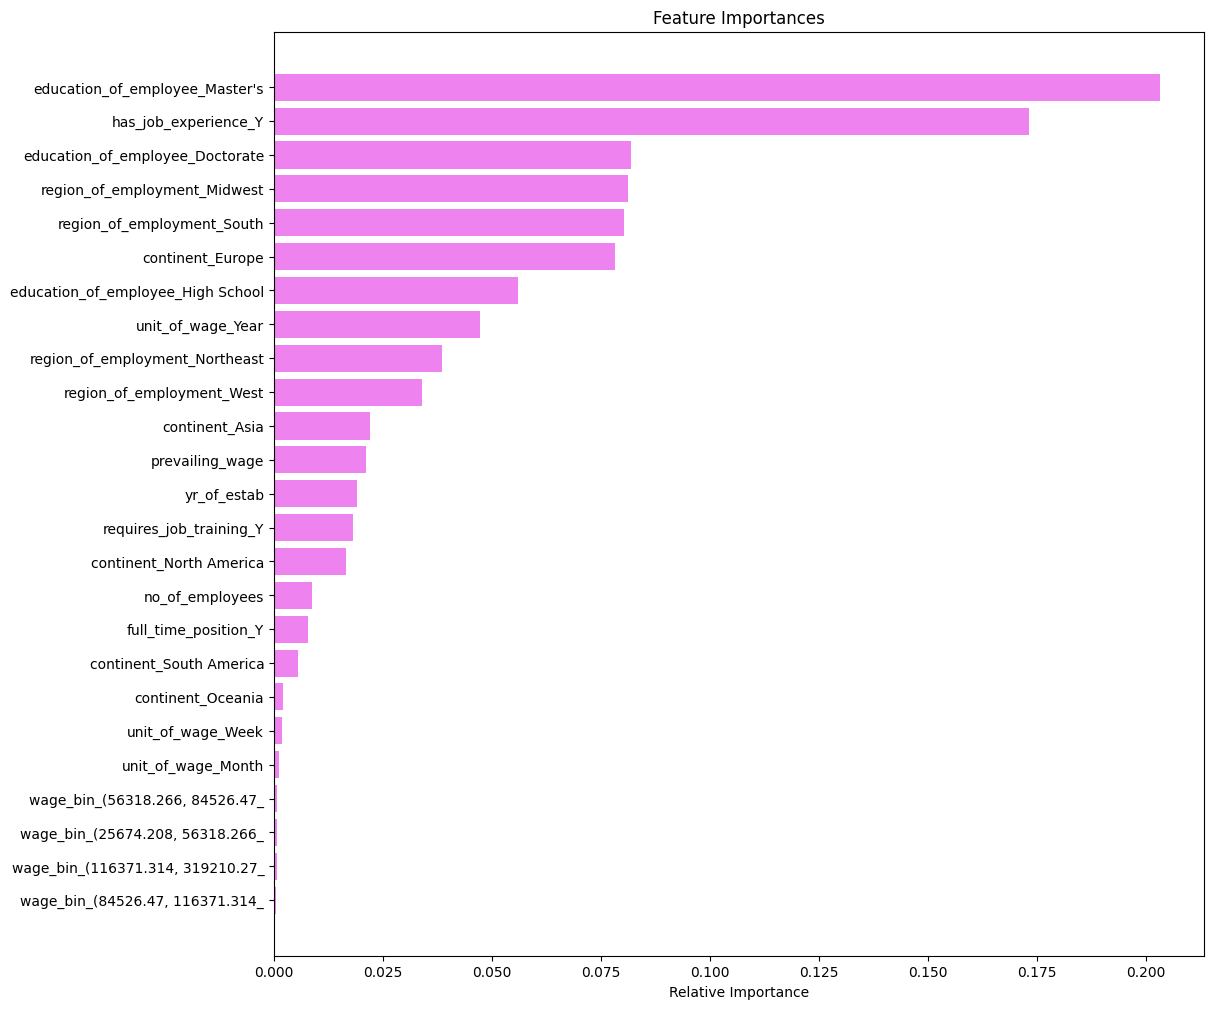

In [131]:
feature_names = X_train.columns
importances = final_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

## Actionable Insights and Recommendations

### Insights

##### **From Exploratory Data Analysis (EDA):**

* **Geographic Origins:**
  * Most (66%) of work visa applicants are from Asia.
  * European applicants have the highest approval rates, while those from South America have the lowest.
* **Educational Background:**
  * Nearly 78% of applicants hold a Bachelor’s or Master’s degree.
  * Less than 9% have a Doctorate.
  * Higher education levels significantly increase the chances of visa approval.
* **Work Experience & Training:**
  * Around 58% of applicants have prior job experience, positively influencing approval.
  * 88% of offered jobs do not require additional training, and this requirement shows little impact on approval.
* **Employment & Job Details:**
  * Over 81% of jobs are located in the Northeast, South, and West regions of the U.S.
  * 89% of offered roles are full-time, but full-time status has no strong correlation** with visa certification.
  * About 90% of positions use ‘Year’ as the wage unit, which correlates with higher approval rates. Hourly wages show the lowest certification likelihood.
* **Employer Characteristics:**
  * Most sponsoring employers have been established for less than 40 years.
  * The Number of company employees and age show minimal impact on visa certification outcomes.
* **Approval Rates:**
  * Roughly two-thirds of all applications are certified.
  * Applicants for jobs in the Midwest have higher chances of certification than those in other regions.

---

#### **From Model Interpretations and Feature Importance:**

* **Model Performance:**
  * All classifiers performed comparably, but the **Tuned Gradient Boosting Classifier** delivered the highest F1-score of 82.12% on the test data, making it the most robust overall.
* **Key Predictive Features:**
  * The top predictors across models include:
    * `education_of_employee`
    * `has_job_experience`
    * `region_of_employment`
    * `unit_of_wage_Year`
    * `continent_Europe`
    * `hourly_wage`
* **Decision Tree Insights (Selected Model):**
  * **Approval Likely When:**
    * The applicant has a Master’s or Doctorate, job experience, and a yearly wage unit.
    * The applicant has at least a Bachelor’s degree, no experience, a yearly wage, and is from Europe.
  * **Denial Likely When:**
    * The applicant has a Bachelor’s or master’s degree, no job experience, and the wage unit is not yearly.
    * Applicant lacks a university degree, is from Asia, and seeks employment in the West or Northeast regions.

---

#### **Strategic Takeaways:**
* **Education & Experience Matter:**
  * Applicants with higher education levels and job experience have significantly greater chances of approval, reinforcing policies aimed at skilled immigration.
* **Wage as a Signal:**
  * Higher prevailing wages**, especially for hourly roles, correlate strongly with visa approval, possibly indicating demand for highly skilled roles.  
* **Model Robustness:**
  * The Tuned Gradient Boosting model maintains a balanced performance across accuracy, precision, recall, and F1-score, making it a dependable tool for predicting visa outcomes.



### Recommendations:
### **1. Final Model Selection**
* A higher-performing ensemble model is preferred to reduce bias and improve generalization; thus, the **Tuned Gradient Boosting Classifier** is recommended as it demonstrated the highest F1 score on the test data.

### **2. Key Applicant Criteria for Certification Prediction**
* The Office of Foreign Labor Certification (OFLC) should prioritize evaluating and incorporating the following features when estimating the likelihood of visa certification:
  * Applicants with a Master’s or Doctorate show significantly higher approval rates.
  * Prior relevant work experience increases the probability of certification.
  * Positions with a yearly wage unit correlate with higher certification outcomes.
  * European applicants tend to have a higher likelihood of approval in certain combinations.

### **3. Resource Optimization Strategies**
* To efficiently utilize OFLC resources:
  * Prioritize applications that score high on key predictive factors (education, experience, wage) to avoid delays in sectors dependent on skilled foreign labor.
  * Streamline rejections by flagging applications with a high predicted likelihood of denial. If appealed, these cases can still be re-evaluated manually, ensuring fairness while saving processing time.

### **5. Model Deployment Guidance**
* Deploy the Tuned Gradient Boost Classifier as a decision-support tool, not a replacement for human judgment.
* Ensure model integration follows legal, ethical, and procedural guidelines, especially for cases where explanations may be legally required.

### **6. Fairness, Transparency, and Ongoing Monitoring**
* Establish a process for regularly auditing model outputs to detect and correct potential biases, especially against applicants in entry-level, hourly-wage, or lower-education roles.
* Maintain transparency about model use in visa decisions to foster trust.
* Continuously update the model with new application data and monitor feature importance over time to adapt to changing labor market dynamics.

### **7. Practical Prioritization Steps**
To maximize impact with constrained resources, OFLC may:
* Sort applications by education level and job experience; prioritize highly qualified candidates first.
* Segment applications by wage unit (hourly vs. annual), and within each group, review higher-paying roles first.
* Use model output to triage applications, accelerating decisions on high-confidence cases while allocating more review time to borderline or ambiguous ones.


<font size=6 color='blue'>Power Ahead</font>
___